**Notes on creating plots that show how connected samples in the graph are**

Produce plots that show:
* connectedness across alignement cutoffs
* number of samples connected across cutoffs
* connectedness growth curves

In [1]:
%cd /private/groups/migalab/juklucas/centrolign/variant_calling/rates

/private/groups/migalab/juklucas/centrolign/variant_calling/rates


# Class Definitions

In [2]:
from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple, Optional
from matplotlib.ticker import FuncFormatter, LogLocator, ScalarFormatter



In [3]:
class PairwiseDistanceIndex:
    """
    Symmetric index over a one-way distance CSV (a,b,dist).
    """

    def __init__(self, distance_csv: str):
        self.distance_csv = distance_csv
        self._dist: Dict[str, Dict[str, float]] = {}

    def load(self) -> "PairwiseDistanceIndex":
        dist = {}
        with open(self.distance_csv) as f:
            for line in f:
                if not line.strip():
                    continue
                a, b, d = line.strip().split(",")
                d = float(d)
                dist.setdefault(a, {})[b] = d
                dist.setdefault(b, {})[a] = d
        self._dist = dist
        return self

    def neighbors_under(self, sample_id: str, threshold: float) -> List[Tuple[str, float]]:
        row = self._dist.get(sample_id, {})
        hits = [(o, d) for o, d in row.items() if d < threshold]
        hits.sort(key=lambda x: x[1])
        return hits
    
class PairwiseAnalyzer:
    def __init__(self, distance_csv: str):
        self.dist = PairwiseDistanceIndex(distance_csv).load()

    def neighbors_under(self, sample_id: str, threshold: float) -> pd.DataFrame:
        hits = self.dist.neighbors_under(sample_id, threshold)
        return pd.DataFrame(hits, columns=["other_id", "distance"])


def get_all_samples(an: PairwiseAnalyzer) -> List[str]:
    return sorted(an.dist._dist.keys())


def neighbors_under_all_samples(an: PairwiseAnalyzer, threshold: float) -> Dict[str, int]:
    return {
        s: len(an.dist.neighbors_under(s, threshold))
        for s in get_all_samples(an)
    }

def sweep_neighbor_thresholds(
    an: PairwiseAnalyzer,
    thresholds: np.ndarray,
) -> pd.DataFrame:
    samples = get_all_samples(an)
    records = []

    for t in thresholds:
        counts = neighbors_under_all_samples(an, t)
        for s in samples:
            n = counts[s]
            records.append(
                dict(
                    threshold=t,
                    sample_id=s,
                    n_neighbors=n,
                    has_neighbor=n > 0,
                )
            )

    return pd.DataFrame(records)


def pangenome_growth_curve(
    an: PairwiseAnalyzer,
    distance_cutoff: float = 0.2,
    n_steps: int = 15,
    n_reps: int = 20,
    random_state: int = 0,
) -> pd.DataFrame:
    rng = np.random.default_rng(random_state)
    all_samples = np.array(get_all_samples(an))
    N = len(all_samples)

    sizes = np.unique(np.linspace(1, N, n_steps, dtype=int))
    records = [{"n_samples": 0, "fraction_connected": 0.0}]

    for k in sizes:
        for _ in range(n_reps):
            subset = rng.choice(all_samples, size=k, replace=False)
            subset_set = set(subset)

            connected = 0
            for s in subset:
                row = an.dist._dist.get(s, {})
                has_nbr = any(
                    (o in subset_set) and (o != s) and (d < distance_cutoff)
                    for o, d in row.items()
                )
                connected += has_nbr

            records.append(
                dict(
                    n_samples=k,
                    fraction_connected=connected / k,
                )
            )

    return pd.DataFrame(records)


def plot_connectivity_summary(
    an: PairwiseAnalyzer,
    chrom_label: str,
    distance_cutoffs=np.linspace(0, 0.5, 25),
    growth_cutoffs=(0.2, 0.4),   # <-- NEW
):
    # ---------- Panels A & B ----------
    df = sweep_neighbor_thresholds(an, distance_cutoffs)

    conn = (
        df.groupby("threshold")["has_neighbor"]
        .mean()
        .reset_index()
    )

    nbrs = (
        df.groupby("threshold")["n_neighbors"]
        .agg(
            median="median",
            q25=lambda x: np.percentile(x, 25),
            q75=lambda x: np.percentile(x, 75),
        )
        .reset_index()
    )

    # ---------- Panel C: growth (MULTIPLE CUTS) ----------
    growth_summaries = {}

    for dcut in growth_cutoffs:
        growth = pangenome_growth_curve(an, distance_cutoff=dcut)
        gsum = (
            growth.groupby("n_samples")["fraction_connected"]
            .agg(
                mean="mean",
                lo=lambda x: np.percentile(x, 10),
                hi=lambda x: np.percentile(x, 90),
            )
            .reset_index()
        )
        growth_summaries[dcut] = gsum

    # ---------- Plot ----------
    fig, axes = plt.subplots(
        1, 3,
        figsize=(12, 3.5),
        gridspec_kw={"wspace": 0.35},
    )

    # ---- Panel A: Connectivity ----
    axes[0].plot(
        conn["threshold"],
        conn["has_neighbor"],
        lw=1.8,
        color="black",
    )
    axes[0].set_ylim(0, 1.02)
    axes[0].set_title("Connectivity")
    axes[0].set_xlabel("Distance cutoff")
    axes[0].set_ylabel("Fraction connected")

    # ---- Panel B: Local density ----
    axes[1].fill_between(
        nbrs["threshold"],
        nbrs["q25"],
        nbrs["q75"],
        color="0.85",
    )
    axes[1].plot(
        nbrs["threshold"],
        nbrs["median"],
        lw=1.8,
        color="black",
    )
    axes[1].set_title("Local density")
    axes[1].set_xlabel("Distance cutoff")
    axes[1].set_ylabel("Neighbors per sample")

    axes[1].set_yscale("log")
    axes[1].set_ylabel("Neighbors per sample (log scale)")
    
    # ---- Panel C: Pangenome growth (two curves) ----
    colors = {
        growth_cutoffs[0]: "black",
        growth_cutoffs[1]: "0.4",
    }

    for dcut, gsum in growth_summaries.items():
        axes[2].fill_between(
            gsum["n_samples"],
            gsum["lo"],
            gsum["hi"],
            color=colors[dcut],
            alpha=0.25,
            linewidth=0,
        )
        axes[2].plot(
            gsum["n_samples"],
            gsum["mean"],
            lw=1.8,
            color=colors[dcut],
            label=f"d ≤ {dcut}",
        )

    axes[2].set_ylim(0, 1.02)
    axes[2].set_title("Pangenome growth")
    axes[2].set_xlabel("Number of samples")
    axes[2].set_ylabel("Fraction connected")
    axes[2].legend(frameon=False, fontsize=9)

    # ---- Shared aesthetics ----
    for ax in axes:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(direction="out", length=3, width=0.8)

    fig.suptitle(
        f"{chrom_label} — pairwise connectivity summary",
        y=1.05,
        fontsize=11,
    )

    plt.tight_layout()
    plt.show()


# Plot Def

In [4]:
def chrom_sort_key(c):
    if c.startswith("chr"):
        c = c[3:]
    if c.isdigit():
        return int(c)
    if c == "X":
        return 23
    if c == "Y":
        return 24
    return 99


## Connectedness and Growth By Chrom

In [5]:
from matplotlib.ticker import FuncFormatter, LogLocator, ScalarFormatter


def plot_multi_chrom_connectivity_summary(
    analyzers_by_chrom: dict,
    distance_cutoffs=np.linspace(0, 1.0, 30),
    growth_cutoffs=(0.2, 0.4),
    output_prefix=None,
):
    chroms = sorted(analyzers_by_chrom.keys(), key=chrom_sort_key)
    nrows = len(chroms)

    # ---------- formatters ----------
    percent_formatter = FuncFormatter(lambda y, _: f"{int(round(y * 100))}%")

    log_plain_formatter = ScalarFormatter()
    log_plain_formatter.set_scientific(False)
    log_plain_formatter.set_useOffset(False)

    fig, axes = plt.subplots(
        nrows,
        3,
        figsize=(12, 2.1 * nrows),
        gridspec_kw={
            "wspace": 0.35,
            "hspace": 0.18,
        },
        sharex="col",
    )

    if nrows == 1:
        axes = axes[None, :]

    for row, chrom in enumerate(chroms):
        an = analyzers_by_chrom[chrom]

        # ---------- Panels A & B ----------
        df = sweep_neighbor_thresholds(an, distance_cutoffs)

        conn = (
            df.groupby("threshold")["has_neighbor"]
            .mean()
            .reset_index()
        )

        nbrs = (
            df.groupby("threshold")["n_neighbors"]
            .agg(
                median="median",
                q25=lambda x: np.percentile(x, 25),
                q75=lambda x: np.percentile(x, 75),
            )
            .reset_index()
        )

        # ---------- Panel C ----------
        growth_summaries = {}
        for dcut in growth_cutoffs:
            growth = pangenome_growth_curve(an, distance_cutoff=dcut)
            gsum = (
                growth.groupby("n_samples")["fraction_connected"]
                .agg(
                    mean="mean",
                    lo=lambda x: np.percentile(x, 10),
                    hi=lambda x: np.percentile(x, 90),
                )
                .reset_index()
            )
            growth_summaries[dcut] = gsum

        # ================== PANEL A ==================
        ax = axes[row, 0]
        ax.plot(conn["threshold"], conn["has_neighbor"], lw=1.3, color="black")
        ax.axhline(1.0, color="0.9", lw=0.7, zorder=0)

        for d in growth_cutoffs:
            ax.axvline(d, color="0.85", lw=0.7, ls="--")

        ax.set_ylim(0, 1.02)
        ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
        ax.yaxis.set_major_formatter(percent_formatter)
        ax.set_ylabel("Fraction connected", fontsize=8)

        # ================== PANEL B ==================
        ax = axes[row, 1]
        ax.fill_between(
            nbrs["threshold"],
            nbrs["q25"],
            nbrs["q75"],
            color="0.8",
            alpha=0.45,
        )
        ax.plot(nbrs["threshold"], nbrs["median"], lw=1.3, color="black")

        for d in growth_cutoffs:
            ax.axvline(d, color="0.85", lw=0.7, ls="--")

        ax.set_yscale("log")
        ax.yaxis.set_major_locator(LogLocator(base=10))
        ax.yaxis.set_major_formatter(log_plain_formatter)
        ax.set_ylabel("Neighbors / sample", fontsize=8)

        # ================== PANEL C ==================
        ax = axes[row, 2]

        colors = {
            growth_cutoffs[0]: "black",
            growth_cutoffs[1]: "#4C72B0",
        }

        for dcut, gsum in growth_summaries.items():
            ax.fill_between(
                gsum["n_samples"],
                gsum["lo"],
                gsum["hi"],
                color=colors[dcut],
                alpha=0.20,
                linewidth=0,
            )
            ax.plot(
                gsum["n_samples"],
                gsum["mean"],
                lw=1.6 if dcut == growth_cutoffs[0] else 1.4,
                color=colors[dcut],
                label=f"d ≤ {dcut}",
            )

        ax.axhline(1.0, color="0.9", lw=0.7, zorder=0)
        ax.set_ylim(0, 1.02)
        ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
        ax.yaxis.set_major_formatter(percent_formatter)
        ax.set_ylabel("Fraction connected", fontsize=8)

        # ---------- X-axis labels on every row ----------
        # axes[row, 0].set_xlabel("Distance cutoff", fontsize=8)
        # axes[row, 1].set_xlabel("Distance cutoff", fontsize=8)
        # axes[row, 2].set_xlabel("Number of samples", fontsize=8)
        for ax in axes[:, 0]:
            ax.tick_params(labelbottom=True)

        for ax in axes[:, 1]:
            ax.tick_params(labelbottom=True)

        for ax in axes[:, 2]:
            ax.tick_params(labelbottom=True)


        # ---------- Row label ----------
        axes[row, 0].text(
            -0.32, 0.5,
            chrom,
            transform=axes[row, 0].transAxes,
            va="center",
            ha="right",
            fontsize=9,
            fontweight="bold",
        )

    # ---------- Column titles ----------
    axes[0, 0].set_title("Connectivity", fontsize=10)
    axes[0, 1].set_title("Local density", fontsize=10)
    axes[0, 2].set_title("Pangenome growth", fontsize=10)

    # ---------- Shared aesthetics ----------
    for ax in axes.flat:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(
            direction="out",
            length=2.5,
            width=0.7,
            labelsize=7,
        )
    axes[-1, 0].set_xlabel("Distance cutoff", fontsize=8)
    axes[-1, 1].set_xlabel("Distance cutoff", fontsize=8)
    axes[-1, 2].set_xlabel("Number of samples", fontsize=8)

    plt.tight_layout(rect=[0, 0, 1, 0.995])

    if output_prefix is not None:
        fig.savefig(f"{output_prefix}.pdf", bbox_inches="tight")
        fig.savefig(f"{output_prefix}.png", dpi=300, bbox_inches="tight")

    plt.show()



## Overlaid Connectedness

In [6]:
from matplotlib.lines import Line2D


def plot_connectivity_all_chromosomes(
    analyzers_by_chrom: dict,
    distance_cutoffs=np.linspace(0, 1.0, 40),
    output_prefix=None,
):
    """
    Plot connectivity vs distance cutoff for all chromosomes on one axis,
    colored by number of assemblies.

    Color bins:
        0–100
        100–200
        200–300
        300–400
    """

    # ----- color bins -----
    bins = [
        (0, 100, "#d73027"),     # red
        (100, 200, "#fc8d59"),   # orange
        (200, 300, "#91bfdb"),   # light blue
        (300, 500, "#4575b4"),   # blue
    ]

    def color_for_n(n):
        for lo, hi, c in bins:
            if lo <= n < hi:
                return c
        return "0.5"  # fallback gray

    fig, ax = plt.subplots(figsize=(5.5, 4))

    for chrom, an in analyzers_by_chrom.items():
        samples = get_all_samples(an)
        n_samples = len(samples)
        color = color_for_n(n_samples)

        df = sweep_neighbor_thresholds(an, distance_cutoffs)
        conn = (
            df.groupby("threshold")["has_neighbor"]
            .mean()
            .reset_index()
        )

        ax.plot(
            conn["threshold"],
            conn["has_neighbor"],
            color=color,
            lw=0.7,
            alpha=0.9,
        )

    # ----- axis formatting -----
    ax.set_xlim(distance_cutoffs.min(), distance_cutoffs.max())
    ax.set_ylim(0, 1.02)

    ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
    ax.yaxis.set_major_formatter(
        FuncFormatter(lambda y, _: f"{int(round(y * 100))}%")
    )

    ax.set_xlabel("Distance cutoff")
    ax.set_ylabel("Assemblies with ≥1 neighbor")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(direction="out", length=3, width=0.8)

    # ----- legend -----
    legend_handles = [
        Line2D([0], [0], color=c, lw=2, label=f"{lo}–{hi} assemblies")
        for lo, hi, c in bins
    ]

    ax.legend(
        handles=legend_handles,
        title="Count bin",
        frameon=False,
        fontsize=9,
        title_fontsize=9,
        loc="lower right",
    )

    ax.set_title("Connectivity vs distance cutoff across chromosomes", fontsize=11)

    plt.tight_layout()

    if output_prefix is not None:
        fig.savefig(f"{output_prefix}.svg", bbox_inches="tight")
        fig.savefig(f"{output_prefix}.png", dpi=600, bbox_inches="tight")

    plt.show()


In [8]:
chroms = [f"chr{i}" for i in range(1, 22)] + ["chrX", "chrY"]
import os
analyzers = {}

for chr_name in chroms:
    dist_csv = f"/private/groups/patenlab/mira/centrolign/batch_submissions/centrolign/release2_QC_v2/all_pairs/distance_matrices/{chr_name}_r2_QC_v2_centrolign_pairwise_distance.csv"

    if not os.path.exists(dist_csv):
        print(f"[warning] missing distance file for {chr_name}")
        break

    analyzers[chr_name] = PairwiseAnalyzer(distance_csv=dist_csv)




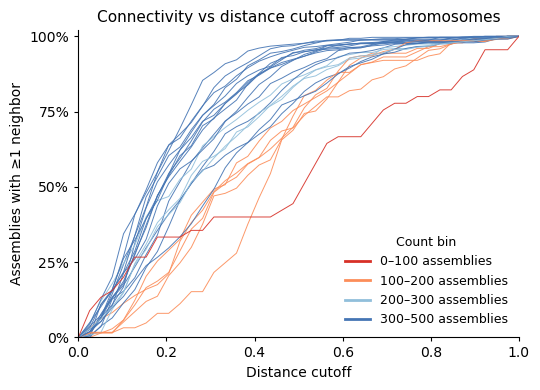

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/private/home/mmastora/miniconda3/envs/ipynb/lib/python3.14/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
    ~~~~~~~~^^
  File "/private/home/mmastora/miniconda3/envs/ipynb/lib/python3.14/site-packages/ipykernel/kernelbase.py", line 577, in shell_channel_thread_main
    _, msg2 = self.session.feed_identities(msg, copy=False)
              ~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "/private/home/mmastora/miniconda3/envs/ipynb/lib/python3.14/site-packages/jupyter_client/session.py", line 994, in feed_identities
    raise ValueError(msg)
ValueError: DELIM not in msg_list
ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/private/home/mmastora/miniconda3/envs/ipynb/lib/python3.14/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
    ~~~~~~~~^^
  File "

In [9]:
plot_connectivity_all_chromosomes(analyzers, output_prefix="/private/groups/patenlab/mira/connectedness_all_chrom_sup")